In [40]:
import pandas as pd

# Uber Cardinality


In [41]:
results_df =  pd.read_csv(r'C:\Users\Ronza\Dev\DP-MSD\Uber\results\results_from_server\Uber_Master_Results_1000_800.csv')

In [42]:
results_df


,alg,k,lambda_param,eps,rep,value,relevance,diversity,queries,time_sec
0,nonpriv,4,0.1,0.2,0,0.892534,0.936050,0.500891,7990,0.3000
1,DPGreedy,4,0.1,0.2,0,0.867054,0.902036,0.552213,7990,0.3074
2,DPSampleOblGreedy,4,0.1,0.2,0,0.891055,0.939144,0.458252,4612,0.1800
3,DPSampleGreedy,4,0.1,0.2,0,0.882669,0.926299,0.489999,5610,0.2172
4,Random,4,0.1,0.2,0,0.386459,0.421595,0.070238,0,0.0000
...,...,...,...,...,...,...,...,...,...,...
1195,nonpriv,6,0.8,0.2,9,0.650672,0.906247,0.586779,11972,0.6364
1196,DPGreedy,6,0.8,0.2,9,0.628985,0.866302,0.569656,11972,0.6155
1197,DPSampleOblGreedy,6,0.8,0.2,9,0.637213,0.896153,0.572478,4612,0.2457
1198,DPSampleGreedy,6,0.8,0.2,9,0.606288,0.899286,0.533038,7028,0.3691


## Impact of k on score


In [43]:
results_df['alg'] = results_df['alg'].replace(
    {
        'nonpriv': 'Greedy',
        'DPGreedy': 'DP-Greedy',
        'DPSampleOblGreedy': 'DP-OSG',
        'DPSampleGreedy': 'DP-NOSG',
        'Random': 'Random'
    }
)

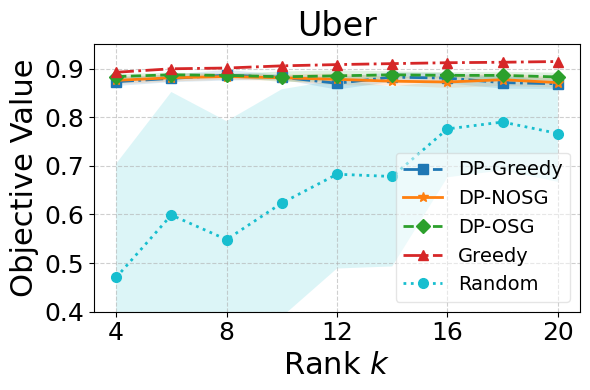

In [60]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter the data for eps=0.1 and lambda_param=0.1
# Using your initial filtering requirements
filtered_df = results_df[(results_df['eps'] == 0.2) & (results_df['lambda_param'] == 0.1)]

# 2. Group by algorithm and 'k' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'k'])['value'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with large text and distinct styles
plt.figure(figsize=(6, 4)) # Large figure size for clarity

# Define specific styles to ensure variety across algorithms
markers = ['s', '*', 'D', '^', 'o', 'x']
linestyles = ['-.', '-', '--', '-.', ':']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#17becf', '#8c564b']

# Get the list of algorithms present in the stats
algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    

    line, = plt.plot(
    alg_data['k'], 
    alg_data['mean'], 
    label=alg,
    color=colors[i % len(colors)],
    marker=markers[i % len(markers)],
    linestyle=linestyles[i % len(linestyles)],
    linewidth=2,
    markersize=7
)
    plt.fill_between(
        alg_data['k'], 
        alg_data['mean'] - alg_data['std'], 
        alg_data['mean'] + alg_data['std'], 
        color=line.get_color(),
        alpha=0.15,  # Low alpha for transparency
        edgecolor='none' # No border around the shade for a softer look
    )
# Formatting for large text relative to the image size
plt.xlabel('Rank $k$', fontsize=22)
plt.ylabel('Objective Value', fontsize=22)
plt.title('Uber', fontsize=24)
plt.ylim(0.4, 0.95)
plt.xticks(range(4, 22, 4), fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=14, frameon=True, ncols=1, framealpha=0.5) # Legend with a box for clarity
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ensures labels don't get cut off
plt.savefig('uber_cardinality_k_on_val.pdf')
plt.show()

In [56]:
import pandas as pd

# 1. Filter the dataset for k <= 60
stats_subset = stats[stats['k'] <= 60].copy()

# 2. Extract the Greedy baseline values for each 'k' in this subset
greedy_ref = stats_subset[stats_subset['alg'] == 'Greedy'][['k', 'mean']].rename(columns={'mean': 'greedy_mean'})

# 3. Merge reference back into the subset
df_merged = pd.merge(stats_subset, greedy_ref, on='k')

# 4. Calculate the % decrease
df_merged['pct_decrease'] = (df_merged['greedy_mean'] - df_merged['mean']) / df_merged['greedy_mean'] * 100

# 5. Group by algorithm to find the average drop for k <= 60
k_60_summary = df_merged.groupby('alg')['pct_decrease'].mean().reset_index()

k_60_summary.columns = ['Algorithm', 'Avg % Below Greedy (k <= 60)']
print(k_60_summary.sort_values(by='Avg % Below Greedy (k <= 60)'))

   Algorithm  Avg % Below Greedy (k <= 60)
3     Greedy                      0.000000
2     DP-OSG                      2.319812
1    DP-NOSG                      3.211032
0  DP-Greedy                      3.215327
4     Random                     27.328326


## Impact of eps on score

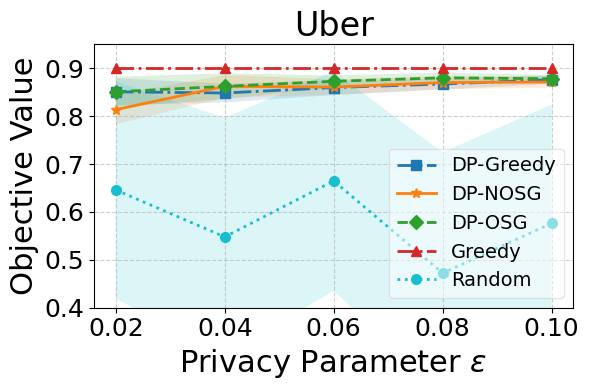

In [61]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Filter the data for k=15 and lambda_param=0.1
target_k = 6 
eps_list = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]

filtered_df = results_df[
    (results_df['k'] == target_k) & 
    (results_df['lambda_param'] == 0.1) & 
    (results_df['eps'].round(2).isin(eps_list)) 
]

# 2. Group by algorithm and 'eps' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'eps'])['value'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with your exact requested sizes
plt.figure(figsize=(6, 4)) # Exact size from your reference

# Define specific styles
markers = ['s', '*', 'D', '^', 'o', 'x']
linestyles = ['-.', '-', '--', '-.', ':']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#17becf', '#8c564b']

algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    line, = plt.plot(
        alg_data['eps'], 
        alg_data['mean'], 
        label=alg,
        color=colors[i % len(colors)],
        marker=markers[i % len(markers)],
        linestyle=linestyles[i % len(linestyles)],
        linewidth=2,
        markersize=7
        )
    plt.fill_between(
        alg_data['eps'], 
        alg_data['mean'] - alg_data['std'], 
        alg_data['mean'] + alg_data['std'], 
        color=line.get_color(),
        alpha=0.15,  # Low alpha for transparency
        edgecolor='none' # No border around the shade for a softer look
         )
    

# Formatting with exact fontsizes from your reference
plt.xlabel('Privacy Parameter $\\varepsilon$', fontsize=22)
plt.ylabel('Objective Value', fontsize=22)
plt.title('Uber', fontsize=24)
plt.ylim(0.4, 0.95)
# Show only even ticks to avoid crowding: 0.02, 0.04, 0.06, 0.08, 0.10
plt.xticks(eps_list[1::2], fontsize=18)
plt.yticks(fontsize=18)

plt.legend(fontsize=14, frameon=True, ncols=1, framealpha=0.5, loc='lower right')# Exact size from your reference
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() 
plt.savefig('uber_cardinality_eps_on_val.pdf')
plt.show()

In [63]:
import pandas as pd

# 1. Filter the dataset for epsilon = 0.1
stats_01 = stats[stats['eps'] == 0.1].copy()

# 2. Identify the Greedy value for this specific epsilon
greedy_val = stats_01[stats_01['alg'] == 'Greedy']['mean'].values[0]

# 3. Calculate percentage decrease for each algorithm
# Formula: (Greedy - Mean) / Greedy * 100
stats_01['pct_below_greedy'] = (greedy_val - stats_01['mean']) / greedy_val * 100

# 4. Display sorted results
comparison = stats_01[['alg', 'mean', 'pct_below_greedy']].sort_values(by='pct_below_greedy')
print(f"Comparison at epsilon = 0.1 (Greedy Reference: {greedy_val:.4f})")
print(comparison.to_string(index=False))

Comparison at epsilon = 0.1 (Greedy Reference: 0.8997)
      alg     mean  pct_below_greedy
   Greedy 0.899724          0.000000
   DP-OSG 0.878147          2.398092
DP-Greedy 0.876291          2.604397
  DP-NOSG 0.871371          3.151312
   Random 0.576179         35.960418


## Impact of k on num queries

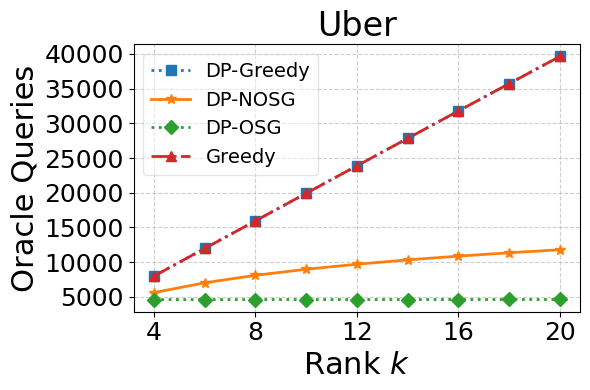

In [52]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter the data for eps=0.1 and lambda_param=0.1
# Using your initial filtering requirements
filtered_df = results_df[
    (results_df['eps'] == 0.2) 
    & (results_df['lambda_param'] == 0.1) 
    & results_df['k'].isin(list(range(4, 22, 2)))
    & ~results_df['alg'].isin(['Random'])
    
]

# 2. Group by algorithm and 'k' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'k'])['queries'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with large text and distinct styles
plt.figure(figsize=(6, 4)) # Large figure size for clarity

# Define specific styles to ensure variety across algorithms
markers = ['s', '*', 'D', '^', 'o', 'x']
linestyles = [':', '-', ':', '-.', '-', '--']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#17becf', '#8c564b']

# Get the list of algorithms present in the stats
algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    # Assign a unique combination of color, marker, and linestyle to each alg
    line, = plt.plot(
    alg_data['k'], 
    alg_data['mean'], 
    label=alg,
    color=colors[i % len(colors)],
    marker=markers[i % len(markers)],
    linestyle=linestyles[i % len(linestyles)],
    linewidth=2,
    markersize=7
    )
    plt.fill_between(
    alg_data['k'], 
    alg_data['mean'] - alg_data['std'], 
    alg_data['mean'] + alg_data['std'], 
    color=line.get_color(),
    alpha=0.15,  # Low alpha for transparency
    edgecolor='none' # No border around the shade for a softer look
     )


# Formatting for large text relative to the image size
plt.xlabel('Rank $k$', fontsize=22)
plt.ylabel('Oracle Queries', fontsize=22)
plt.title('Uber', fontsize=24)

plt.xticks(range(4, 22, 4), fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=14, frameon=True, ncols=1, framealpha=0.5)# Legend with a box for clarity
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ensures labels don't get cut off
plt.savefig('uber_k_on_queries.pdf')
plt.show()

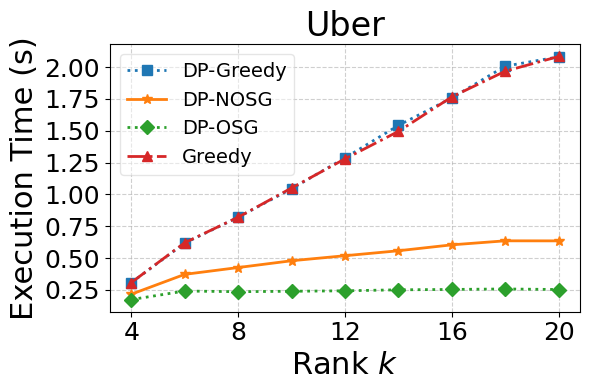

In [47]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter the data for eps=0.1 and lambda_param=0.1
# Using your initial filtering requirements
filtered_df = results_df[
    (results_df['eps'] == 0.2) 
    & (results_df['lambda_param'] == 0.1) 
    & results_df['k'].isin(list(range(4, 22, 2)))
    & ~results_df['alg'].isin(['Random'])
    
]

# 2. Group by algorithm and 'k' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'k'])['time_sec'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with large text and distinct styles
plt.figure(figsize=(6, 4)) # Large figure size for clarity

# Define specific styles to ensure variety across algorithms
markers = ['s', '*', 'D', '^', 'o', 'x']
linestyles = [':', '-', ':', '-.', '-', '--']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#17becf', '#8c564b']

# Get the list of algorithms present in the stats
algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    # Assign a unique combination of color, marker, and linestyle to each alg
    line, = plt.plot(
    alg_data['k'], 
    alg_data['mean'], 
    label=alg,
    color=colors[i % len(colors)],
    marker=markers[i % len(markers)],
    linestyle=linestyles[i % len(linestyles)],
    linewidth=2,
    markersize=7
    )
    # plt.fill_between(
    # alg_data['k'], 
    # alg_data['mean'] - alg_data['std'], 
    # alg_data['mean'] + alg_data['std'], 
    # color=line.get_color(),
    # alpha=0.15,  # Low alpha for transparency
    # edgecolor='none' # No border around the shade for a softer look
    #  )


# Formatting for large text relative to the image size
plt.xlabel('Rank $k$', fontsize=22)
plt.ylabel('Execution Time (s)', fontsize=22)
plt.title('Uber', fontsize=24)

plt.xticks(range(4, 22, 4), fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=14, frameon=True, ncols=1, framealpha=0.5)# Legend with a box for clarity
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ensures labels don't get cut off
plt.savefig('uber_k_on_time.pdf')
plt.show()

In [48]:
stats[stats['alg'] == 'DP-OSG']

,alg,k,mean,std
18,DP-OSG,4,0.17395,0.002958
19,DP-OSG,6,0.24105,0.017574
20,DP-OSG,8,0.23583,0.008729
21,DP-OSG,10,0.23916,0.005196
22,DP-OSG,12,0.24285,0.013098
23,DP-OSG,14,0.25062,0.013712
24,DP-OSG,16,0.25352,0.017711
25,DP-OSG,18,0.25725,0.018199
26,DP-OSG,20,0.25293,0.003769


## Impact of lambda on score

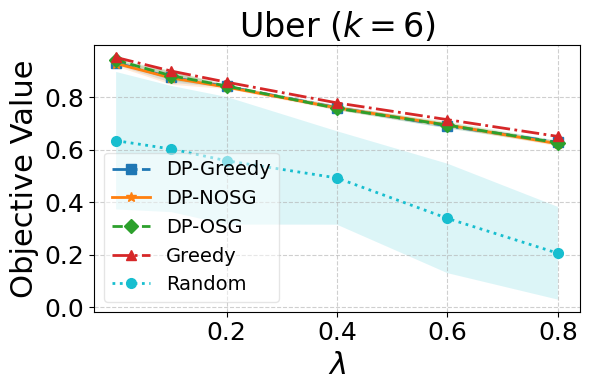

In [49]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Filter the data for k=15 and lambda_param=0.1
target_k = 6
lambda_list = [0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

filtered_df = results_df[
    (results_df['k'] == target_k) 
    # (results_df['lambda_param'].round(2).isin(eps_list)) 
]

# 2. Group by algorithm and 'eps' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'lambda_param'])['value'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with your exact requested sizes
plt.figure(figsize=(6, 4)) # Exact size from your reference

# Define specific styles
markers = ['s', '*', 'D', '^', 'o', 'x']
linestyles = ['-.', '-', '--', '-.', ':']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#17becf', '#8c564b']

algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    line, = plt.plot(
    alg_data['lambda_param'], 
    alg_data['mean'], 
    label=alg,
    color=colors[i % len(colors)],
    marker=markers[i % len(markers)],
    linestyle=linestyles[i % len(linestyles)],
    linewidth=2,
    markersize=7
    )
    plt.fill_between(
    alg_data['lambda_param'], 
    alg_data['mean'] - alg_data['std'], 
    alg_data['mean'] + alg_data['std'], 
    color=line.get_color(),
    alpha=0.15,  # Low alpha for transparency
    edgecolor='none' # No border around the shade for a softer look
     )    
    # plt.errorbar(
    #     alg_data['eps'], 
    #     alg_data['mean'], 
    #     yerr=alg_data['std'], 
    #     label=alg,
    #     color=colors[i % len(colors)],
    #     marker=markers[i % len(markers)],
    #     linestyle=linestyles[i % len(linestyles)],
    #     linewidth=2.5,  
    #     markersize=6,   # Exact size from your reference
    #     capsize=6       
    # )

# Formatting with exact fontsizes from your reference
plt.xlabel('$\\lambda$', fontsize=22)
plt.ylabel('Objective Value', fontsize=22)
plt.title('Uber ($k=6$)', fontsize=24)

# Show only even ticks to avoid crowding: 0.02, 0.04, 0.06, 0.08, 0.10
plt.xticks(lambda_list[1::2], fontsize=18)
plt.yticks(fontsize=18)

plt.legend(fontsize=14, frameon=True, ncols=1, framealpha=0.5)# Exact size from your reference
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() 
plt.savefig('uber_cardinality_lambda_on_val.pdf')
plt.show()

In [50]:
print(stats)

          alg  lambda_param      mean       std
0   DP-Greedy           0.0  0.930968  0.007624
1   DP-Greedy           0.1  0.875565  0.020281
2   DP-Greedy           0.2  0.841032  0.004148
3   DP-Greedy           0.4  0.760456  0.008812
4   DP-Greedy           0.6  0.690524  0.009044
5   DP-Greedy           0.8  0.628463  0.004819
6     DP-NOSG           0.0  0.928630  0.010771
7     DP-NOSG           0.1  0.873628  0.026242
8     DP-NOSG           0.2  0.838550  0.007031
9     DP-NOSG           0.4  0.759370  0.009497
10    DP-NOSG           0.6  0.694029  0.008744
11    DP-NOSG           0.8  0.622650  0.009396
12     DP-OSG           0.0  0.941602  0.002544
13     DP-OSG           0.1  0.881873  0.019527
14     DP-OSG           0.2  0.842863  0.004581
15     DP-OSG           0.4  0.757643  0.007327
16     DP-OSG           0.6  0.693660  0.012874
17     DP-OSG           0.8  0.626124  0.008257
18     Greedy           0.0  0.951731  0.000000
19     Greedy           0.1  0.899724  0

In [51]:
import pandas as pd

# Assuming your DataFrame is named 'stats'
# 1. Extract the Greedy baseline values for each lambda
greedy_baseline = stats[stats['alg'] == 'Greedy'][['lambda_param', 'mean']].rename(columns={'mean': 'greedy_mean'})

# 2. Merge the greedy baseline back into the stats table
df_merged = pd.merge(stats, greedy_baseline, on='lambda_param')

# 3. Calculate the percentage decrease for each row
# Formula: (Greedy_Value - Current_Value) / Greedy_Value * 100
df_merged['pct_decrease'] = (df_merged['greedy_mean'] - df_merged['mean']) / df_merged['greedy_mean'] * 100

# 4. Compute the average decrease across all lambda choices for each algorithm
final_comparison = df_merged.groupby('alg')['pct_decrease'].mean().reset_index()

# Formatting for a clean display
final_comparison.columns = ['Algorithm', 'Avg % Decrease vs Greedy']
print(final_comparison.sort_values(by='Avg % Decrease vs Greedy'))

   Algorithm  Avg % Decrease vs Greedy
3     Greedy                  0.000000
2     DP-OSG                  2.355715
0  DP-Greedy                  2.647344
1    DP-NOSG                  2.862828
4     Random                 43.202715
